In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

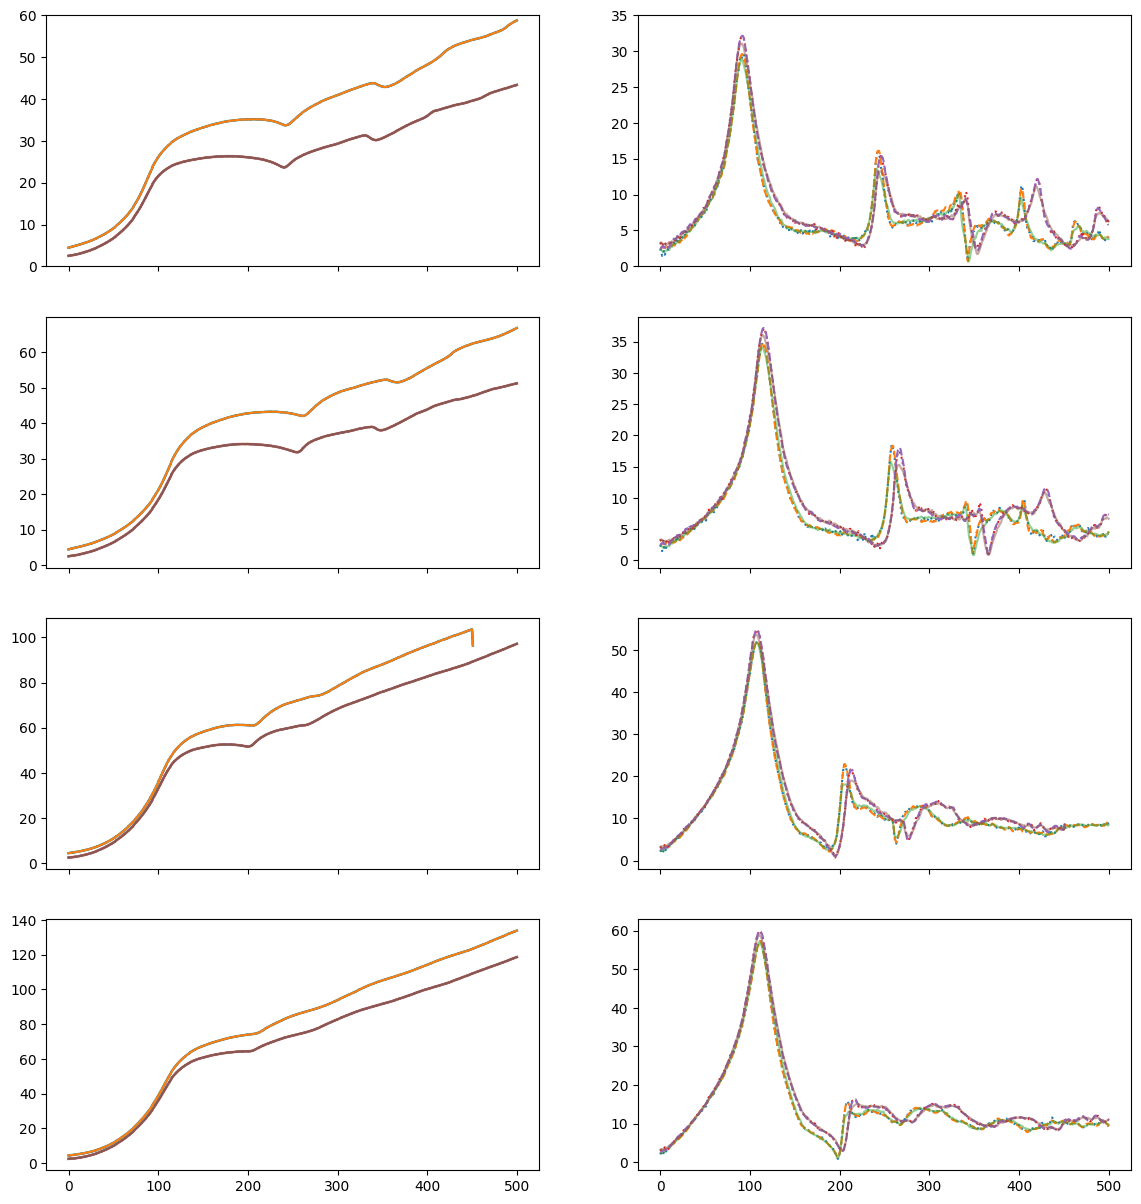

In [2]:
base_path = "../../scripts/output"

def load_and_norm(file_path, cols):
    """Load file and return norm over selected columns."""
    data = np.loadtxt(file_path)
    return np.linalg.norm(data[:, cols], axis=1)

# Parameters to iterate over
i_values = range(3, 7)  # MWLMC3, MWLMC4, MWLMC5
b_values = ["b1", "b0"] # Possible b-values

fig, ax = plt.subplots(4, 2, figsize=(14, 15), sharex=True)
j=0
for i in i_values:
    for b in b_values:
        folder = f"MWLMC{i}"
        base_name = f"MWLMC{i}_100M_{b}_vir_OM3_G4"

        files = {
            "bulge_nba": f"{base_path}/{folder}/{base_name}_nba_bulge_pot.txt",
            "disk_nba":  f"{base_path}/{folder}/{base_name}_nba_disk_pot.txt",
            "halo_nba":  f"{base_path}/{folder}/{base_name}_nba_halo_pot.txt",
            "halo_pb":   f"{base_path}/{folder}/{base_name}_pb_halo_pot.txt",
            "halo_ssc":  f"{base_path}/{folder}/{base_name}_pb_halo_ssc.txt",
            "disk_pb":   f"{base_path}/{folder}/{base_name}_pb_disk_pot.txt",
        }

        # Plot positions (cols 0–2)
        ax[j][0].plot(load_and_norm(files["bulge_nba"], slice(0, 3)), ls=':')
        ax[j][0].plot(load_and_norm(files["disk_nba"],  slice(0, 3)), ls='--')
        ax[j][0].plot(load_and_norm(files["halo_nba"],  slice(0, 3)), ls='-', alpha=0.5)
        ax[j][0].plot(load_and_norm(files["halo_pb"],   slice(0, 3)), lw=2, alpha=0.4)
        ax[j][0].plot(load_and_norm(files["halo_ssc"],  slice(0, 3)))
        ax[j][0].plot(load_and_norm(files["disk_pb"],   slice(0, 3)))

        # Plot velocities (cols 3+)
        ax[j][1].plot(load_and_norm(files["bulge_nba"], slice(3, None)), ls=':')
        ax[j][1].plot(load_and_norm(files["disk_nba"],  slice(3, None)), ls='--')
        ax[j][1].plot(load_and_norm(files["halo_nba"],  slice(3, None)), ls='-', alpha=0.5)
    j+=1
ax[0][0].set_ylim(0, 60)
ax[0][1].set_ylim(0, 35)

plt.show()


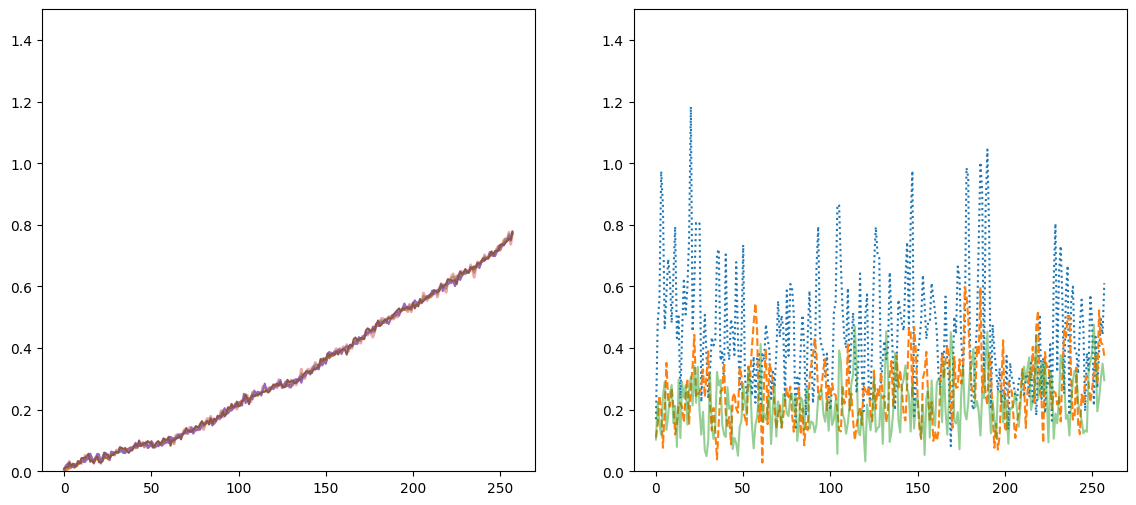

In [3]:
base_path = "../../scripts/output"

def load_and_norm(file_path, cols):
    """Load file and return norm over selected columns."""
    data = np.loadtxt(file_path)
    return np.linalg.norm(data[:, cols], axis=1)


fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
folder = "MW"
base_name = "MW_100M_beta1_vir_OM3_G4"

files = {
    "bulge_nba": f"{base_path}/{folder}/{base_name}_nba_bulge_pot.txt",
    "disk_nba":  f"{base_path}/{folder}/{base_name}_nba_disk_pot.txt",
    "halo_nba":  f"{base_path}/{folder}/{base_name}_nba_halo_pot.txt",
    "halo_pb":   f"{base_path}/{folder}/{base_name}_pb_halo_pot.txt",
    "halo_ssc":  f"{base_path}/{folder}/{base_name}_pb_halo_ssc.txt",
    "disk_pb":   f"{base_path}/{folder}/{base_name}_pb_disk_pot.txt",
}

# Plot positions (cols 0–2)
ax[0].plot(load_and_norm(files["bulge_nba"], slice(0, 3)), ls=':')
ax[0].plot(load_and_norm(files["disk_nba"],  slice(0, 3)), ls='--')
ax[0].plot(load_and_norm(files["halo_nba"],  slice(0, 3)), ls='-', alpha=0.5)
ax[0].plot(load_and_norm(files["halo_pb"],   slice(0, 3)), lw=2, alpha=0.4)
ax[0].plot(load_and_norm(files["halo_ssc"],  slice(0, 3)))
ax[0].plot(load_and_norm(files["disk_pb"],   slice(0, 3)))

# Plot velocities (cols 3+)
ax[1].plot(load_and_norm(files["bulge_nba"], slice(3, None)), ls=':')
ax[1].plot(load_and_norm(files["disk_nba"],  slice(3, None)), ls='--')
ax[1].plot(load_and_norm(files["halo_nba"],  slice(3, None)), ls='-', alpha=0.5)

ax[0].set_ylim(0, 1.5)
ax[1].set_ylim(0, 1.5)

plt.show()


In [14]:
MODELS = ['GC21M1b0', 'GC21M1b1',  'GC21M2b0', 'GC21M2b1', 'GC21M3b0', 'GC21M3b1', 'GC21M4b0', 'GC21M4b1']
for m in MODELS:
    t, x, y, z, vx, vy, vz = np.loadtxt('./{}_orbit_lmc.txt'.format(m), unpack=True)
    pos = np.sqrt(x**2 + y**2 + z**2)
    peri = np.argmin(pos)
    print(np.abs(t[0]+t[peri]))

1.86
1.8800000000000001
2.2800000000000002
2.2800000000000002
2.2
2.22
2.2800000000000002
2.2800000000000002


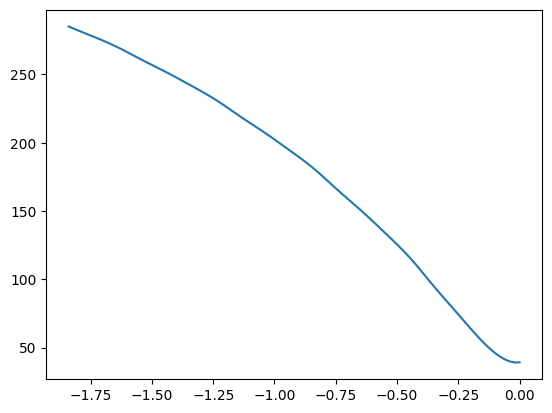

In [8]:
plt.plot(t, np.sqrt(x**2 + y**2 + z**2))